# Lecture 3: Activations, Gradients, and Batch Normalization

In last lecture I built an MLP that learns character embeddings and predicts the next character from a 3-character context window. It worked. But I was lucky: the network was shallow and small. The moment you scale to 4-10 layers, training breaks in silent, confusing ways. Loss stalls. Gradients vanish. The network looks like it is running but nothing is actually being learned.

This notebook teaches you to see inside the network while it trains, catch problems early, and fix them systematically. Three problems, four diagnostic visualizations.

---

### The three problems

**1. Bad initialization.** With 27 characters, a uniform model gives loss = -log(1/27) = 3.29 at the start. My initial loss in last lecture was 27.88. That means the first thousands of training steps were wasted just dragging the loss back to where it should have started, before any real learning could happen. The fix is a one-line weight scale at initialization.

**2. Saturated tanh.** If weights are too large, the pre-activations going into tanh are huge, and tanh squashes them all to exactly -1 or +1. In those flat regions the gradient is zero. Those neurons never update. Half the network is dead before training even starts.

**3. Batch Normalization.** The modern fix for both problems above (Ioffe and Szegedy, 2015). Instead of hand-tuning initialization, BatchNorm forces the pre-activations to be roughly Gaussian (mean 0, std 1) after every layer, automatically, throughout all of training. It is what made training reliably deep networks possible.

### The four diagnostic visualizations

1. Forward pass activation statistics: are neurons saturated?
2. Backward pass gradient statistics: are gradients dying?
3. Weight gradient-to-data ratio: are updates too small or too large?
4. Update/data ratio over time: is the learning rate actually doing anything?

These are the tools practitioners use to debug real networks. After this notebook you can look at a training run and tell immediately what is wrong.

## Setup

Same dataset and vocabulary and 3: 32,033 names, 27 symbols (26 letters plus `.` as the start/end token). I rebuild `stoi` and `itos`, wrap the dataset builder in a function, shuffle, and cut 80/10/10 train/dev/test splits.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
with open("../data/names.txt", "r", encoding="utf-8") as file:
    words = file.read().splitlines()

In [4]:
print(len(words))
words[:8]

32033


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

`stoi` maps each character to an integer, `itos` maps back. The `.` token is index 0 and doubles as start and end marker.

In [5]:
chars = sorted(set(''.join(words)))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(itos)
print(vocab_size)

27


In [7]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


Each split is a pair `(X, Y)` where `X[k]` is a 3-character context and `Y[k]` is the correct next character. About 182k examples in train, 22k each in dev and test.

## Problem 1: Bad initialization (the hockey-stick loss curve)

### Why the initial loss should be 3.29

The model knows nothing at initialization. It should assign equal probability to all 27 characters, 1/27 each. The expected loss for a perfectly uniform model is:

```python
-torch.tensor(1/27.0).log()  # = 3.2958
```

### What actually happens with default random weights

With `W2` sampled from a standard Gaussian, the output logits are large and uneven. Softmax sees big differences and drives one character to near-probability-1 while collapsing the rest to near zero. The model is wildly overconfident from step 1, before seeing any data.

Before the fix, the very first step prints loss = 27.88. The first ~10k training iterations are completely wasted just undoing that random overconfidence instead of learning anything.

Think of it like voting. Before the fix: logits are `[32, -17, 51, -3, ...]` and softmax gives the highest one 99% of the vote. Very confident. Very wrong. After the fix: logits are `[0.32, -0.17, 0.51, -0.03, ...]`, differences are tiny, softmax splits votes roughly equally at ~1/27 each.

### The fix

Scale `W2` by 0.01 and zero out `b2` at initialization. Tiny weights give logits near zero. No strong differences, softmax stays roughly uniform.

In [8]:
-torch.tensor(1/27.0).log()

tensor(3.2958)

Training without the fix. Loss starts at 26.54. I stop after a few steps since I only need to see the hockey-stick start.

In [10]:
g = torch.Generator().manual_seed(2147483647)
n_embd  = 10
n_hidden = 200
block_size = 3

C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

# show the damage: loss at step 0 with default random W2
ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yb)
print(f'initial loss (no fix): {loss.item():.4f}')

initial loss (no fix): 26.5404


With `W2 * 0.01`: loss starts at 3.32, right where it should be. Training is productive from the very first step.

Full 200,000-step training run with Fix 1 applied. Loss starts correctly and steadily descends.

In [11]:
g = torch.Generator().manual_seed(2147483647)
n_embd  = 10
n_hidden = 200
block_size = 3

C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden, generator=g)
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01   # Fix 1
b2 = torch.zeros(vocab_size)                                    # Fix 1

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3316
  10000/ 200000: 2.0309
  20000/ 200000: 2.4608
  30000/ 200000: 2.1378
  40000/ 200000: 1.8895
  50000/ 200000: 2.4275
  60000/ 200000: 2.5294
  70000/ 200000: 2.6240
  80000/ 200000: 2.0888
  90000/ 200000: 2.2594
 100000/ 200000: 2.2979
 110000/ 200000: 2.3206
 120000/ 200000: 2.0845
 130000/ 200000: 1.8010
 140000/ 200000: 2.0361
 150000/ 200000: 1.9098
 160000/ 200000: 1.7958
 170000/ 200000: 1.7777
 180000/ 200000: 2.2478
 190000/ 200000: 2.2831


In [12]:
@torch.no_grad()
def split_loss(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb = C[x]
    h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0693349838256836
val 2.1326169967651367


Fix 1 alone: train 2.06, val 2.13. Not dramatic in final loss but the training curve is now clean from the start.

## Problem 2: Saturated tanh (dead neurons)

Two terms to keep clear going forward:

- `input @ weights + bias` is the **pre-activation** (what enters tanh)
- `tanh(pre-activation)` is the **activation** (what exits tanh)

### What saturation looks like

With default `W1` initialization, the pre-activations `hpreact` spread between roughly -15 and +15. tanh squashes everything outside (-3, +3) to exactly -1 or +1. The histogram of `h` shows almost all neurons piled at the two extremes with almost nothing in the middle.

In those flat regions, the gradient of tanh is zero. Not small, zero. Backpropagation tries to update these neurons but gets no signal through. They are called dead neurons and they never recover.

### The tap analogy

Think of a tap with hot and cold water, handle controlling the mix.

A healthy neuron is a handle in the middle: a small turn left gives slightly colder water, a small turn right slightly warmer. Sensitive to small changes. Learns from every update.

A saturated neuron is a handle slammed to the end: water is either boiling or ice cold with nothing in between. You keep turning but nothing changes. The gradient is zero at the extremes. Backpropagation tries to adjust the neuron but if it is saturated, no adjustment has any effect. The neuron is stuck.

### Why activation functions exist at all

Think of a chef.

Without an activation function the chef can only mix ingredients. No matter how many steps he takes, the result is always a weighted sum, one flat linear taste. Two linear layers collapse into one: `(x @ W1) @ W2` is just `x @ (W1 @ W2)`, still one linear layer.

An activation function is what lets the chef fry, boil, bake. The same ingredients produce completely different results depending on how they are combined. That is what tanh does: it introduces non-linearity so the network can detect patterns no single matrix multiply could capture.

### The fix

Scale down `W1` at initialization so pre-activations stay in the active middle range of tanh where the gradient is healthy:

In [13]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2    # Fix 2
b1 = torch.randn(n_hidden, generator=g) * 0.01                          # Fix 2
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01            # Fix 1
b2 = torch.zeros(vocab_size)                                             # Fix 1

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3256
  10000/ 200000: 1.9593
  20000/ 200000: 2.4088
  30000/ 200000: 2.0775
  40000/ 200000: 1.8977
  50000/ 200000: 2.5250
  60000/ 200000: 2.5539
  70000/ 200000: 2.6676
  80000/ 200000: 2.0147
  90000/ 200000: 2.0605
 100000/ 200000: 2.1413
 110000/ 200000: 2.2308
 120000/ 200000: 2.0230
 130000/ 200000: 1.8165
 140000/ 200000: 2.0328
 150000/ 200000: 1.9401
 160000/ 200000: 1.8604
 170000/ 200000: 1.8120
 180000/ 200000: 2.2642
 190000/ 200000: 2.0638


In [14]:
split_loss('train')
split_loss('val')

train 2.034486770629883
val 2.101991653442383


After `W1 * 0.2` and `b1 * 0.01`: the tanh histogram shows neurons spread across the full active range instead of piled at the endpoints. The pre-activation histogram is roughly Gaussian between -4 and +4. The saturation map (white = saturated, black = active) is almost entirely black with only a few scattered white dots, no fully dead neurons.

Full 200k training result: train 2.035, val 2.102. An improvement, and earned not by changing architecture but by fixing initialization.

Fix 1 stopped wasted iterations at the start. Fix 2 stopped half the neurons being dead at init, letting gradients flow through the full network. Two small multipliers, no architecture changes, meaningful improvement.

| Fix | Train | Val |
|---|---|---|
| Original | 2.124 | 2.168 |
| Fix 1: scale down W2 | 2.069 | 2.132 |
| Fix 2: scale down W1, b1 | 2.034 | 2.101 |

### Why this is catastrophic in deep networks

Our network is shallow: one hidden layer. Even with bad initialization it eventually learned, just slower. In a 50-layer network, saturated neurons in layer 1 kill the gradient before it reaches layer 2. By layer 10 the gradient is essentially zero. Not slower, just stuck. The deeper the network, the more catastrophic bad initialization becomes.

## Kaiming Initialization

Scaling `W1 * 0.2` worked here, but that `0.2` was a guess. Change the layer size and the right number is different. There is a principled derivation.

### The core problem

Matrix multiplication with `n` inputs naturally scales the output by `sqrt(n)`. If weights are too large, activations explode layer over layer. If too small, they shrink to zero. Both kill learning.

### The fix: divide by sqrt(fan_in)

```python
W = torch.randn(fan_in, fan_out) / fan_in ** 0.5
```

`fan_in` is the number of inputs to that layer. Dividing by `sqrt(fan_in)` cancels out the natural growth from matrix multiplication. Activations stay stable at roughly unit variance through every layer.

For tanh specifically, a correction factor of `5/3` is applied because tanh slightly shrinks the spread of activations (it is not perfectly linear even near zero). The `5/3` compensates for that shrinkage. This is called the tanh gain:

```python
W = torch.randn(fan_in, fan_out) * (5/3) / fan_in ** 0.5
```

Think of it as a pump and a leak. tanh is the leak: every pass through it slightly shrinks the spread. The `5/3` gain on the linear layer is the pump: it boosts the spread back before the next tanh shrinks it again. `5/3` makes pump equal leak, so spread stays stable at roughly 0.65 through all layers.

- Gain too small (1.0): leak wins, spread shrinks to zero, neurons output near 0, network learns nothing
- Gain too large (3.0): pump wins, spread grows, neurons saturate at +/-1, gradients die
- Gain = `5/3`: pump = leak, stable spread, low saturation, gradients flow

I do not know exactly where `5/3` came from mathematically. It was found empirically to work well for a Linear + Tanh sandwich.

In [15]:
# demonstrate the scaling problem std of x @ W grows with fan_in
x = torch.randn(1000, 10)
W = torch.randn(10, 200)
y = x @ W
print('input std:', x.std().item())
print('output std (no scaling):', y.std().item())   # grows by sqrt(10) ~ 3.16
y_scaled = x @ (W / 10**0.5)
print('output std (/ sqrt(fan_in)):', y_scaled.std().item())   # stays near 1

input std: 1.005151629447937
output std (no scaling): 3.1712985038757324
output std (/ sqrt(fan_in)): 1.0028525590896606


In [16]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size) ** 0.5
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3325
  10000/ 200000: 1.9600
  20000/ 200000: 2.3784
  30000/ 200000: 2.0733
  40000/ 200000: 1.9263
  50000/ 200000: 2.5024
  60000/ 200000: 2.5346
  70000/ 200000: 2.4997
  80000/ 200000: 2.0271
  90000/ 200000: 2.0743
 100000/ 200000: 2.1018
 110000/ 200000: 2.2375
 120000/ 200000: 2.0760
 130000/ 200000: 1.7971
 140000/ 200000: 1.9591
 150000/ 200000: 1.9417
 160000/ 200000: 1.7372
 170000/ 200000: 1.8694
 180000/ 200000: 2.2353
 190000/ 200000: 2.0969


In [17]:
split_loss('train')
split_loss('val')

train 2.0377914905548096
val 2.1029715538024902


Kaiming result: train 2.037, val 2.102. Same territory as Fix 2, but now the scale is derived from the architecture rather than guessed. Change the layer size and the formula automatically gives the right scale.

In practice today: people use `(5/3) / sqrt(fan_in)` and move on. BatchNorm (next section) makes initialization less critical anyway. The deeper lesson is understanding why, so when something breaks in a deep network you know where to look.

## Batch Normalization (Ioffe and Szegedy, 2015)

Kaiming initialization is careful setup before training. BatchNorm is a self-correcting mechanism during training.

### The core idea

Instead of carefully initializing weights so activations stay well-behaved, just force them to be well-behaved after every layer. BatchNorm applies z-normalization to the pre-activations before they enter tanh:

```
hpreact = embcat @ W1 + b1
hpreact = (hpreact - mean) / std     <== mean=0, std=1 guaranteed
h       = tanh(hpreact)
```

The formula:

$$\hat{x} = \frac{x - \mu_B}{\sigma_B}$$

where the mean and std are computed across the batch (the 32 examples in the mini-batch), separately for each of the 100 neurons. This is the "batch" in BatchNorm: you normalize using statistics across the current batch.

### Why keepdim=True matters

```python
x    = [[1, 2, 3],    # shape (2, 3)
        [4, 5, 6]]

mean = x.mean(0, keepdim=True)   # shape (1, 3), one mean per neuron
                                  # [[2.5, 3.5, 4.5]]

x - mean                          # broadcasts correctly: shape (2, 3)
```

Without `keepdim=True`, mean would be shape `(3,)` and still broadcast correctly, but `keepdim=True` makes the intent explicit and matters in more complex cases.

### gamma and beta: learnable scale and shift

Pure normalization forces every layer to always have mean=0 and std=1, which is too rigid. The network might genuinely need a different scale or offset at some layer. So after normalizing, BatchNorm applies:

```python
output = gamma * x_normalized + beta
```

`gamma` (scale) starts at 1 and `beta` (shift) starts at 0, which is the identity: does nothing at initialization. Then gradient descent moves them wherever needed.

Imagine a chef who receives all ingredients pre-washed, pre-cut, perfectly portioned. That is BatchNorm normalizing: everything is clean and standard. But then the chef adds his own seasoning, salt and pepper to taste. That is `gamma` and `beta`: the network starts with clean normalized values, then learns how much to season each layer to get the best result.

### b1 becomes redundant

Once BatchNorm follows the linear layer, any constant offset added by `b1` gets subtracted right back out during normalization. `bnbias` (beta) already handles the offset role. Keeping `b1` wastes parameters and does nothing.

In [18]:
x = torch.randn(32, 5)
print('shape of x:', x.shape)
print('mean(0, keepdim=True) shape:', x.mean(0, keepdim=True).shape)
print('centered mean:', (x - x.mean(0, keepdim=True)).mean(0).abs().max().item())

shape of x: torch.Size([32, 5])
mean(0, keepdim=True) shape: torch.Size([1, 5])
centered mean: 7.450580596923828e-09


BatchNorm inserted inline into the training loop. `bnmean` and `bnstd` are computed from the current mini-batch each step. `bngain` and `bnbias` are added to the parameters list and trained by gradient descent.

In [19]:
g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size) ** 0.5
# no b1, BatchNorm subtracts the mean, so b1 has zero effect
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.zeros(vocab_size)

bngain = torch.ones( (1, n_hidden))    # gamma, starts at 1 (identity)
bnbias = torch.zeros((1, n_hidden))    # beta,  starts at 0 (identity)
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones( (1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(-1, n_embd * block_size)
    hpreact = embcat @ W1   # (32, 200), no b1

    # BatchNorm normalize across the batch for each of the 200 neurons
    bnmeani  = hpreact.mean(0, keepdim=True)
    bnstdi   = hpreact.std(0, keepdim=True)
    hpreact  = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    # update running statistics for inference (no_grad not part of the compute graph)
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3061
  10000/ 200000: 2.1946
  20000/ 200000: 2.4035
  30000/ 200000: 2.4287
  40000/ 200000: 2.2463
  50000/ 200000: 2.4028
  60000/ 200000: 2.3382
  70000/ 200000: 2.0429
  80000/ 200000: 2.3376
  90000/ 200000: 2.2240
 100000/ 200000: 1.9628
 110000/ 200000: 1.9117
 120000/ 200000: 2.2054
 130000/ 200000: 2.3636
 140000/ 200000: 2.2938
 150000/ 200000: 1.8043
 160000/ 200000: 2.2510
 170000/ 200000: 1.9993
 180000/ 200000: 2.1203
 190000/ 200000: 2.3940


In [20]:
# evaluate using running stats (inference mode, single examples are fine)
@torch.no_grad()
def split_loss_bn(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    emb = C[x]
    embcat = emb.view(-1, n_embd * block_size)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss_bn('train')
split_loss_bn('val')

train 2.0657856464385986
val 2.109243631362915


BatchNorm result: train 2.065, val 2.109. The val loss is slightly better than Kaiming because the batch statistics add a small amount of noise during training, which acts as a regularizer and improves generalization.

## Calibrating BatchNorm for inference

During training, BatchNorm normalizes using the mean and std of each mini-batch (32 examples). At inference, you feed one example at a time. You cannot compute meaningful statistics from a single sample.

Two solutions:

**Option A (calibration pass):** after training is done, do one forward pass over the entire training set and record its mean and std. These become fixed constants used at inference.

**Option B (running statistics, used in practice):** during training, maintain a running estimate of mean and std that slowly accumulates across all mini-batches:

```python
bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi
```

Each mini-batch nudges the estimate slightly without forgetting the past. By the end of 200k steps it has converged to a reliable estimate of the full training set. At inference, set `model.eval()` and use the running stats instead of computing per batch.

### Why nobody likes BatchNorm

BatchNorm couples examples in the forward pass. The loss for example 37 in a batch now depends on what examples 1-36 look like, because the mean and std are computed across all of them. This causes subtle, hard-to-find bugs:

- Train and eval behavior differ (batch stats vs. running stats)
- Batch size affects results in unexpected ways
- Easy to accidentally use the wrong stats at inference


### What replaced BatchNorm

Modern deep learning mostly uses:

- **Layer Normalization**: normalizes across features for a single example, no coupling between examples. Used in every transformer (GPT, BERT, etc.) 
- **Group Normalization**: normalizes within groups of channels, useful for vision

In [21]:
# evaluate using running stats (inference mode, single examples are fine)
@torch.no_grad()
def split_loss_bn(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    emb = C[x]
    embcat = emb.view(-1, n_embd * block_size)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss_bn('train')
split_loss_bn('val')

train 2.0657856464385986
val 2.109243631362915


With running stats, no calibration step needed: the model is ready to generate names immediately after training. The train/val loss is essentially identical to the calibration version.

## Summary of fixes: full progression

| Fix | What it solved | Train | Val |
|---|---|---|---|
| Original | nothing | 2.124 | 2.168 |
| W2 * 0.01 | hockey-stick loss, wasted early steps | 2.069 | 2.132 |
| W1 * 0.2 + b1 * 0.01 | saturated tanh, dead neurons | 2.034 | 2.101 |
| Kaiming init | principled scaling, no guessing | 2.037 | 2.102 |
| Batch Normalization | activations controlled throughout training | 2.065 | 2.109 |

BatchNorm did not dramatically improve final loss on this dataset. The optimization is no longer the bottleneck. The bottleneck is the context length: the model still only sees 3 characters. To push further, we need more powerful architectures, which is where the series goes next.

## PyTorch-ifying: `Linear`, `BatchNorm1d`, `Tanh`

Until now all parameters lived as loose variables: `W1`, `b1`, `W2`, `b2`, `bngain`, `bnbias`. That works for a 2-layer network. Add 5 more layers and you have 20 variable names and a forward pass that manually wires each one. The standard solution is to wrap each layer type into a class that owns its weights and knows its own forward pass, exactly like `torch.nn` does internally.

Three methods every layer class has:
- `__init__`: runs once at creation, builds the weight matrices
- `__call__`: runs when data passes through: `x = layer(x)`
- `parameters`: returns all trainable tensors so the optimizer can update them

### class Linear

`torch.randn(...) / fan_in**0.5` is Kaiming initialization built in. `bias=False` is used when BatchNorm follows, since BatchNorm subtracts the mean anyway and the bias would have no effect.

In [26]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

### class BatchNorm1d

`self.training` is the train/eval switch: when `True`, compute stats from the current batch and update running stats; when `False`, use the accumulated running stats for single-example inference.

`eps=1e-5` prevents division by zero if a neuron's variance is exactly 0.

`momentum=0.1` controls running stat updates: 90% old estimate, 10% current batch.

`gamma` and `beta` are the only parameters trained by backprop. Running stats are updated manually inside `__call__`, not by gradients.

In [27]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps # prevents division by zero if a neuron's variance is exactly 0
        self.momentum = momentum # controls running stat updates
        self.training = True
        self.gamma = torch.ones(dim) 
        self.beta = torch.zeros(dim)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar  = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)  # xhat is the normalized input
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

### class Tanh

No weights. Just applies the function and stores the output for later gradient inspection. `parameters()` returns an empty list.

In [67]:
class Tanh:
    def __call__(self, x):
        self.out = x.tanh()
        if self.out.requires_grad:       
            self.out.retain_grad()
        return self.out

## The deep network (6 layers + BatchNorm)

With the three classes I can build a much deeper network as a simple list. Six Linear layers and five Tanh layers alternating, each Linear followed by a BatchNorm. The forward pass is a one-line loop:

```python
for layer in layers:
    x = layer(x)
```

The last layer is a `BatchNorm1d(vocab_size)` with no Tanh after it, feeding directly into the cross-entropy loss.

Two initialization tweaks applied after construction:

- `layers[-1].gamma *= 0.1`: scales down the last BatchNorm's gamma to make output logits small at init, fixing the overconfident softmax problem. Same idea as `W2 * 0.01` before, just applied to gamma since the last layer is now BatchNorm, not Linear.
- `layer.weight *= 1.0` for hidden Linear layers: the slot for the `5/3` tanh gain exists here, but BatchNorm handles scaling automatically so it is left at 1.0.

Total parameters: 47,024.

In [80]:
g = torch.Generator().manual_seed(2147483647)

n_embd   = 10
n_hidden = 100
block_size = 3

C = torch.randn((vocab_size, n_embd), generator=g)

layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False),             BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False),           BatchNorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *= 0.1      # fix overconfident softmax at init
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 1.0  # BatchNorm handles scaling; 5/3 gain slot left at 1.0

parameters = [C]
for layer in layers:
    if hasattr(layer, 'parameters'):
        parameters += layer.parameters()

for p in parameters:
    p.requires_grad = True

print(sum(p.nelement() for p in parameters), 'parameters')

47024 parameters


### The training loop with diagnostics

Two additions beyond the standard loop:

**`layer.out.retain_grad()`**: PyTorch normally discards gradients of intermediate tensors (not parameters) after `backward()`. This call tells PyTorch to keep them so the visualization cells can inspect gradient flow through each layer.

**`ud` list**: at every step, for each parameter, compute the ratio of update size to parameter size:

```python
((lr * p.grad).std() / p.data.std()).log10()
```

This answers: how large is the actual weight change relative to the weight itself? Stored in `ud` for the fourth visualization.

In [81]:
max_steps  = 200000
batch_size = 32
lossi = []
ud    = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb]                        # (32, 3, 10)
    x   = emb.view(emb.shape[0], -1)   # (32, 30)
    for layer in layers:
        x = layer(x)
    logits = x                         # (32, 27)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()   # keep intermediate gradients for visualization
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([
            ((lr * p.grad).std() / p.data.std()).log10().item()
            for p in parameters
        ])
    # if i >= 1000:  
       # break # take out obviously to run full optimization

      0/ 200000: 3.3313
  10000/ 200000: 2.2421
  20000/ 200000: 2.2097
  30000/ 200000: 2.3876
  40000/ 200000: 2.2931
  50000/ 200000: 2.7929
  60000/ 200000: 2.1761
  70000/ 200000: 2.3427
  80000/ 200000: 1.8958
  90000/ 200000: 2.2789
 100000/ 200000: 2.2481
 110000/ 200000: 1.8559
 120000/ 200000: 2.1814
 130000/ 200000: 2.3896
 140000/ 200000: 1.6139
 150000/ 200000: 2.1558
 160000/ 200000: 2.1824
 170000/ 200000: 1.9608
 180000/ 200000: 1.7548
 190000/ 200000: 1.8213


In [70]:
for layer in layers:
    layer.training = False   # switch to inference mode use running stats

@torch.no_grad()
def split_loss_deep(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    emb = C[x]
    x   = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())

split_loss_deep('train')
split_loss_deep('val')

train 2.403294563293457
val 2.402827501296997


## Visualization 1: Forward pass activation statistics

After training, each Tanh layer has an `out` tensor. For each Tanh layer I look at:
- the mean (should be near 0)
- the std (should be stable across layers)
- the saturation fraction: percentage of neurons with `|out| > 0.97`, meaning stuck in the flat region where gradient is zero

Only Tanh layers are checked because their output is always in (-1, 1), a fixed range that is easy to interpret. Linear and BatchNorm outputs can be any number.

layer  2 (      Tanh): mean -0.00, std 0.63, saturated: 3.18%
layer  5 (      Tanh): mean +0.01, std 0.64, saturated: 2.80%
layer  8 (      Tanh): mean +0.00, std 0.64, saturated: 2.36%
layer 11 (      Tanh): mean +0.01, std 0.65, saturated: 2.10%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%


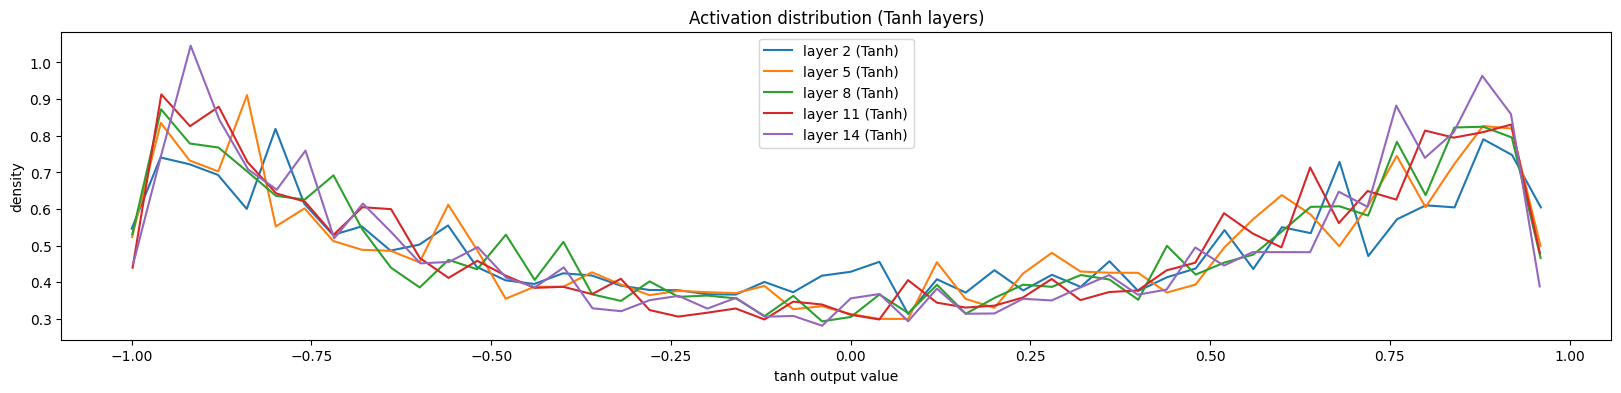

In [71]:
# Visualization 1: forward pass activation statistics (Tanh layers only)
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers):
    if isinstance(layer, Tanh):
        t = layer.out
        sat = (t.abs() > 0.97).float().mean().item() * 100
        print(f'layer {i:2d} ({type(layer).__name__:>10s}): '
              f'mean {t.mean():+.2f}, std {t.std():.2f}, saturated: {sat:.2f}%')
        hy, hx = torch.histogram(t, density=True, bins=50)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({type(layer).__name__})')
plt.legend(legends)
plt.title('Activation distribution (Tanh layers)')
plt.xlabel('tanh output value')
plt.ylabel('density')
plt.show()

**Reading the numbers:**

```
layer  2 (      Tanh): mean -0.00, std 0.63, saturated: 3.18%
layer  5 (      Tanh): mean +0.01, std 0.64, saturated: 2.80%
layer  8 (      Tanh): mean +0.00, std 0.64, saturated: 2.36%
layer 11 (      Tanh): mean +0.01, std 0.65, saturated: 2.10%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.81%
```

Mean near 0: activations are centered. Std around 0.65 across all 5 layers: activations are not collapsing or exploding. Saturation below 3%: fewer than 3 neurons in 100 are stuck at the flat ends of tanh where the gradient is zero. This is a healthy network.

Without BatchNorm and the `5/3` gain, std would drift: too small gain means each tanh squashes it further each layer until it collapses to zero (dead network); too large means each layer's spread grows until everything saturates. BatchNorm makes the std stable automatically.

## Visualization 2: Backward pass gradient statistics

Same loop, but instead of `layer.out` I look at `layer.out.grad`, the gradient flowing backward through each Tanh layer. All 5 layers should have roughly the same gradient distribution: same shape, same spread. Equal gradient std = all layers learning at roughly the same speed.

In [74]:
# Re-run one training forward+backward so layer.out.grad is populated
for layer in layers:
    layer.training = True          # back to train mode

emb = C[Xtr[:32]]                 # small batch is fine, just need gradients
x   = emb.view(emb.shape[0], -1)
for layer in layers:
    x = layer(x)
loss = F.cross_entropy(x, Ytr[:32])
loss.backward()                    # this populates layer.out.grad for Tanh layers

layer  2 (      Tanh): mean -0.000000000, std 3.583953e-03
layer  5 (      Tanh): mean -0.000000000, std 2.999024e-03
layer  8 (      Tanh): mean +0.000000000, std 2.702959e-03
layer 11 (      Tanh): mean +0.000000000, std 2.419137e-03
layer 14 (      Tanh): mean -0.000000000, std 2.437041e-03


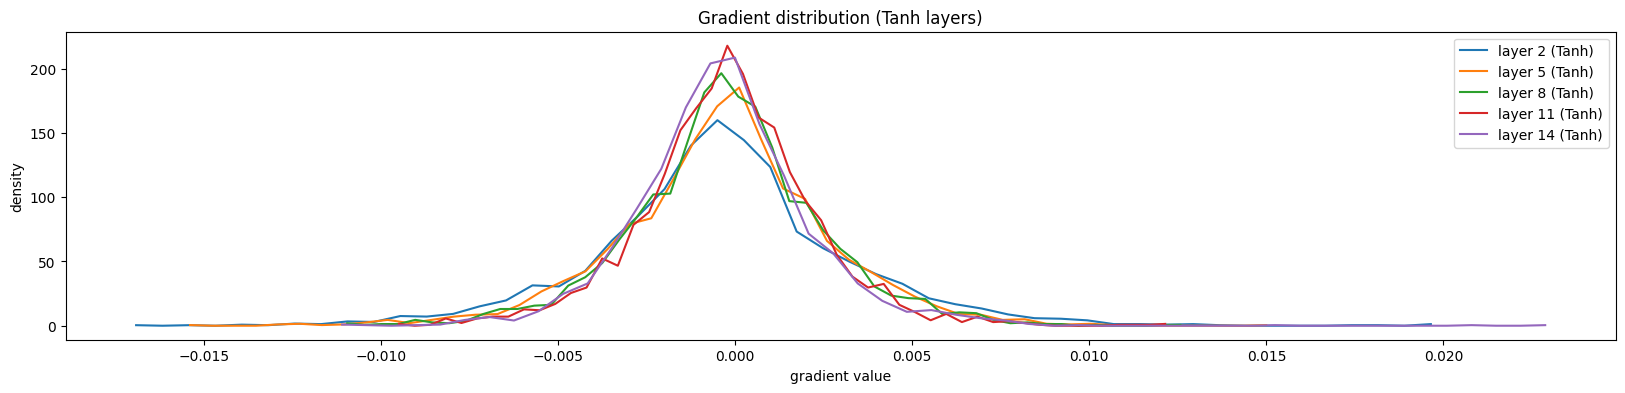

In [75]:
# Visualization 2: backward pass gradient statistics (Tanh layers only)
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers):
    if isinstance(layer, Tanh):         
        t = layer.out.grad
        print(f'layer {i:2d} ({type(layer).__name__:>10s}): '
              f'mean {t.mean():+.9f}, std {t.std():e}')
        hy, hx = torch.histogram(t, density=True, bins=50)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({type(layer).__name__})')
plt.legend(legends)
plt.title('Gradient distribution (Tanh layers)')
plt.xlabel('gradient value')
plt.ylabel('density')
plt.show()

**Reading the numbers:**

```
layer  2 (      Tanh): mean -0.000000000, std 3.583953e-03
layer  5 (      Tanh): mean -0.000000000, std 2.999024e-03
layer  8 (      Tanh): mean +0.000000000, std 2.702959e-03
layer 11 (      Tanh): mean +0.000000000, std 2.419137e-03
layer 14 (      Tanh): mean -0.000000000, std 2.437041e-03
```

Slightly decreasing from layer 2 to 14 but all in the same order of magnitude. No vanishing, no exploding. A broken network would show clearly separated lines: vanishing gradients would make early-layer curves much narrower than later ones (gradients shrinking as they travel backward), exploding gradients would make early-layer curves much wider.

Without BatchNorm, getting both forward and backward pass healthy simultaneously required precisely tuning the gain. One wrong number breaks both. With BatchNorm, the normalization at each layer keeps both healthy automatically.

## Visualization 3: Weight gradient-to-data ratio

The previous two visualizations looked at gradients flowing through intermediate outputs. This one looks directly at the gradients of the actual weight matrices: `W1`, `W2`, and the embedding table `C`.

The key metric is the grad:data ratio:

```python
p.grad.std() / p.data.std()
```

This answers: how large is the gradient relative to the weight itself? If one layer's ratio is 10x larger than others, that layer receives 10x stronger updates and trains faster than the rest. Uneven training.

weight     (27, 10) | mean +0.000000 | std 1.473229e-02 | grad:data ratio 1.471772e-02
weight    (30, 100) | mean -0.000696 | std 1.716586e-02 | grad:data ratio 9.067922e-02
weight   (100, 100) | mean -0.000061 | std 1.289617e-02 | grad:data ratio 1.260935e-01
weight   (100, 100) | mean +0.000087 | std 1.101284e-02 | grad:data ratio 1.074047e-01
weight   (100, 100) | mean -0.000031 | std 9.539781e-03 | grad:data ratio 9.366561e-02
weight   (100, 100) | mean -0.000000 | std 9.208598e-03 | grad:data ratio 9.051897e-02
weight    (100, 27) | mean -0.000155 | std 2.037410e-02 | grad:data ratio 1.958768e-01


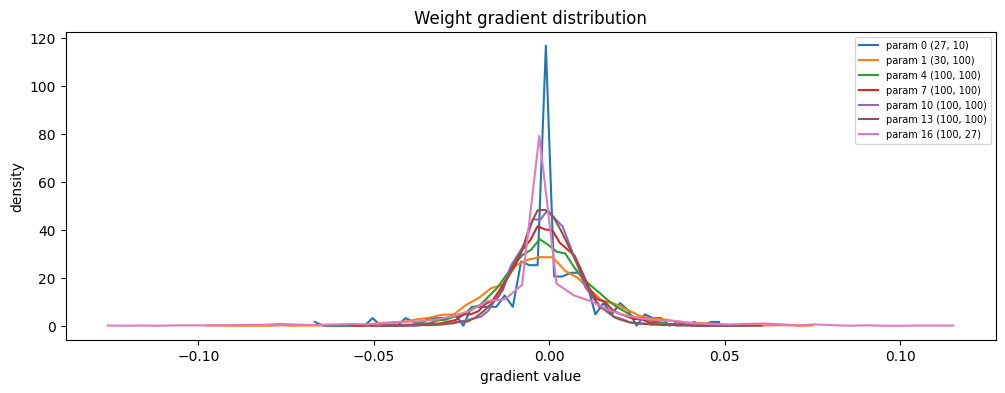

In [77]:
# Visualization 3: weight gradient-to-data ratio
plt.figure(figsize=(12, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:  # weight matrices only (skip biases, gammas, betas which are 1D)
        ratio = p.grad.std() / p.data.std()
        print(f'weight {str(tuple(p.shape)):>12s} | mean {p.grad.mean():+.6f} | '
            f'std {p.grad.std():.6e} | grad:data ratio {ratio:.6e}')
        hy, hx = torch.histogram(p.grad, density=True, bins=50)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'param {i} {tuple(p.shape)}')
plt.legend(legends, fontsize=7)
plt.title('Weight gradient distribution')
plt.xlabel('gradient value')
plt.ylabel('density')
plt.show()

**Reading the numbers:**

```
weight     (27, 10) | mean +0.000000 | std 1.473229e-02 | grad:data ratio 1.471772e-02
weight    (30, 100) | mean -0.000696 | std 1.716586e-02 | grad:data ratio 9.067922e-02
weight   (100, 100) | mean -0.000061 | std 1.289617e-02 | grad:data ratio 1.260935e-01
weight   (100, 100) | mean +0.000087 | std 1.101284e-02 | grad:data ratio 1.074047e-01
weight   (100, 100) | mean -0.000031 | std 9.539781e-03 | grad:data ratio 9.366561e-02
weight   (100, 100) | mean -0.000000 | std 9.208598e-03 | grad:data ratio 9.051897e-02
weight    (100, 27) | mean -0.000155 | std 2.037410e-02 | grad:data ratio 1.958768e-01
```

The last layer (100, 27) has a ratio roughly 10x larger than the others. It is receiving stronger updates than every other layer. This is a mild problem that partially fixes itself as training progresses, but it illustrates exactly why the `gamma *= 0.1` initialization fix matters: scaling down gamma reduces the last layer's gradient at the start.

In a healthy network all weight matrices would have similar grad:data ratios, all lines overlapping in the histogram. In practice: switch to Adam, which normalizes updates per parameter automatically, and this becomes much less of an issue.

## Visualization 4: Update/data ratio over time

The previous visualizations were single snapshots. This one tracks the actual weight changes over all training steps for every parameter. The ratio plotted is:

```python
((lr * p.grad).std() / p.data.std()).log10()
```

This is the update size divided by the weight size, in log10 scale. It captures the full picture because you can have large gradients but a tiny learning rate and the real update is still small.

The target is -3 on the log scale, meaning updates are about 0.1% of the weight values each step. Above -3 (like -2 or -1): updates too large, training unstable. Below -3 (like -4 or -5): updates too small, barely learning.

The last layer (scaled down at init) starts very low and climbs toward -3 as training progresses. Most other lines sit near -2.5, slightly above the target, meaning the learning rate could be slightly lower. If all lines clustered exactly at -3, the learning rate and initialization would be perfectly calibrated.

In practice: use Adam and tune the learning rate. Most of the asymmetry between layers disappears without manual intervention.

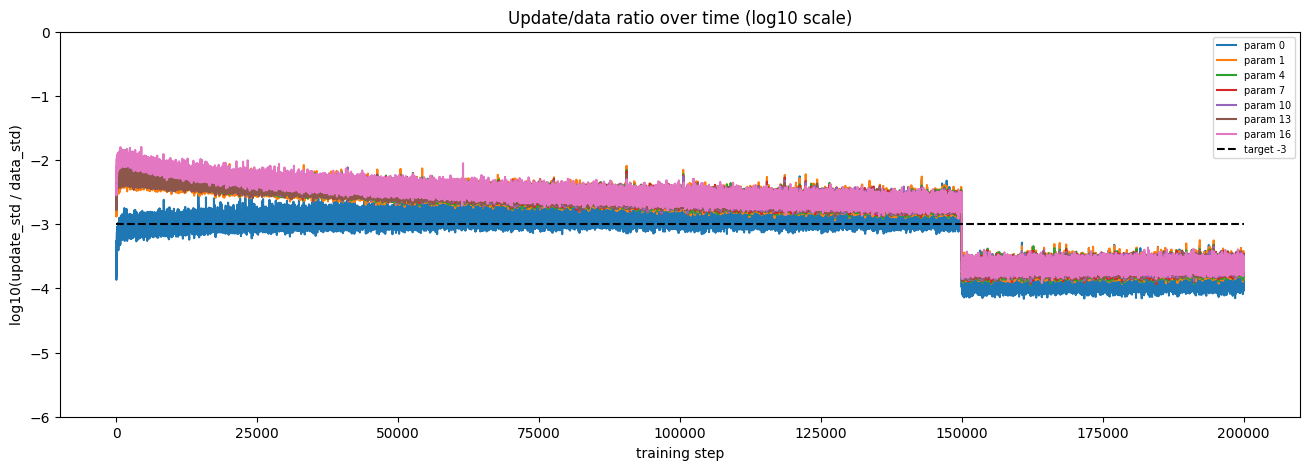

In [82]:
# Visualization 4: update/data ratio over time
plt.figure(figsize=(16, 5))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k--', linewidth=1.5, label='target: -3')
plt.legend(legends + ['target -3'], fontsize=7)
plt.title('Update/data ratio over time (log10 scale)')
plt.xlabel('training step')
plt.ylabel('log10(update_std / data_std)')
plt.ylim(-6, 0)
plt.show()

## Summary

| Topic | What we built | Key insight |
|---|---|---|
| Bad initialization | Scale W2 * 0.01 at init | Loss starts at 3.29, not 27. No wasted steps. |
| Saturated tanh | Scale W1 * 0.2 at init | Keeps pre-activations in tanh's active range. Dead neurons drop from ~50% to near zero. |
| Kaiming init | `W * (5/3) / sqrt(fan_in)` | Principled version of the same fix. Scale is derived from architecture, not guessed. |
| Batch Normalization | Normalize pre-activations each layer | Activations controlled throughout training. Deep networks become trainable. |
| PyTorch-ifying | `Linear`, `BatchNorm1d`, `Tanh` classes | Clean modular code. The API built here is identical to `torch.nn`. |
| Diagnostic tools | 4 visualizations | Forward activations, backward gradients, weight grad ratios, update/data ratio over time. |

BatchNorm did not improve final loss here because the bottleneck shifted: we only see 3 characters of context and the model has saturated what that context can offer. The next step is more powerful architectures, where everything covered in this notebook becomes mandatory. In a 100-layer unrolled RNN, activations and gradients either stay healthy through all 100 layers or training fails completely. These tools are not optional at that scale.